In [16]:
# %% [markdown]
# # Detección de Regímenes y Anomalías en XAUUSD (Oro) usando Deep Learning
# Modelado estadístico para identificar transiciones entre desequilibrio y balance.

# %%
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

In [17]:
# Configuración visual
plt.style.use('seaborn-v0_8-grid' if 'seaborn-v0_8-grid' in plt.style.available else 'ggplot')

In [10]:
# ==========================================
# 1. OBTENCIÓN Y PREPARACIÓN DE DATOS (XAUUSD)
# ==========================================
# 'GC=F' es el ticker de Yahoo Finance para los futuros del Oro (Gold)
ticker = "GC=F" 
print(f"Descargando datos históricos para {ticker} (Oro)...")
data = yf.download(ticker, start="2016-01-01", end="2026-05-25")

# Limpieza de columnas
if 'Adj Close' in data.columns:
    df = data[['Adj Close']].copy()
    df.columns = ['Close']
elif 'Close' in data.columns:
    df = data[['Close']].copy()
else:
    raise ValueError("La descarga de Yahoo Finance no contiene 'Adj Close' ni 'Close'. Verifica el ticker o la conexión.")

df = df.dropna()

# Rendimientos logarítmicos
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

# Construcción de características cuantitativas (Ventanas móviles)
df['Volatilidad_5d'] = df['Log_Return'].rolling(window=5).std()
df['Volatilidad_21d'] = df['Log_Return'].rolling(window=21).std()
df['Media_21d'] = df['Log_Return'].rolling(window=21).mean()
df['Z_Score'] = (df['Log_Return'] - df['Media_21d']) / df['Volatilidad_21d']

df = df.dropna()

[*********************100%***********************]  1 of 1 completed

Descargando datos históricos para GC=F (Oro)...


In [11]:
# ==========================================
# 2. DEFINICIÓN ESTADÍSTICA DE REGÍMENES
# ==========================================
# Definimos umbral estadístico: Anomalía si el movimiento supera 1.96 desviaciones estándar (95% de confianza)
THRESHOLD = 1.96
df['Desequilibrio'] = (df['Z_Score'].abs() > THRESHOLD).astype(int)

# Features para la red neuronal
feature_cols = ['Log_Return', 'Volatilidad_5d', 'Volatilidad_21d', 'Z_Score']
X = df[feature_cols].values
y = df['Desequilibrio'].values

# Escalado de datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División de datos (Manteniendo el orden cronológico para series temporales)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle=False)

In [12]:
# ==========================================
# 3. CONSTRUCCIÓN DE LA RED NEURONAL (Keras)
# ==========================================
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid') # Salida probabilística: [0 = Balance, 1 = Desequilibrio]
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

print("\nEntrenando la red neuronal para detección de regímenes...")
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Entrenando la red neuronal para detección de regímenes...
Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8702 - loss: 0.5158 - precision: 0.0710 - recall: 0.1009 - val_accuracy: 0.9423 - val_loss: 0.3733 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9394 - loss: 0.3502 - precision: 0.1667 - recall: 0.0092 - val_accuracy: 0.9423 - val_loss: 0.2569 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9426 - loss: 0.2656 - precision: 0.6250 - recall: 0.0459 - val_accuracy: 0.9423 - val_loss: 0.2037 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9458 - loss: 0.2167 - precision: 0.8333 - recall: 0.0917 - val_accuracy: 0.9519 - val_loss: 0.1691 - val_precision: 1.0000 - val_recall: 0.1667
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9474 - loss: 0.1861 -

In [13]:
# ==========================================
# 4. PREDICCIÓN Y ESTRATEGIA DE SEÑALES
# ==========================================
# Predecir sobre todo el dataset para la visualización
df['Probabilidad_Desequilibrio'] = model.predict(X_scaled)

# Generar señales estratégicas de compra/venta por Reversión a la Media
# Si el mercado está en desequilibrio extremo negativo (Z_Score < -1.96) y la red detecta anomalía -> COMPRA (esperando reversión)
# Si está en desequilibrio extremo positivo (Z_Score > 1.96) y la red detecta anomalía -> VENTA
df['Señal'] = 0
df.loc[(df['Probabilidad_Desequilibrio'] > 0.7) & (df['Z_Score'] < -THRESHOLD), 'Señal'] = 1  # Compra
df.loc[(df['Probabilidad_Desequilibrio'] > 0.7) & (df['Z_Score'] > THRESHOLD), 'Señal'] = -1  # Venta

81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


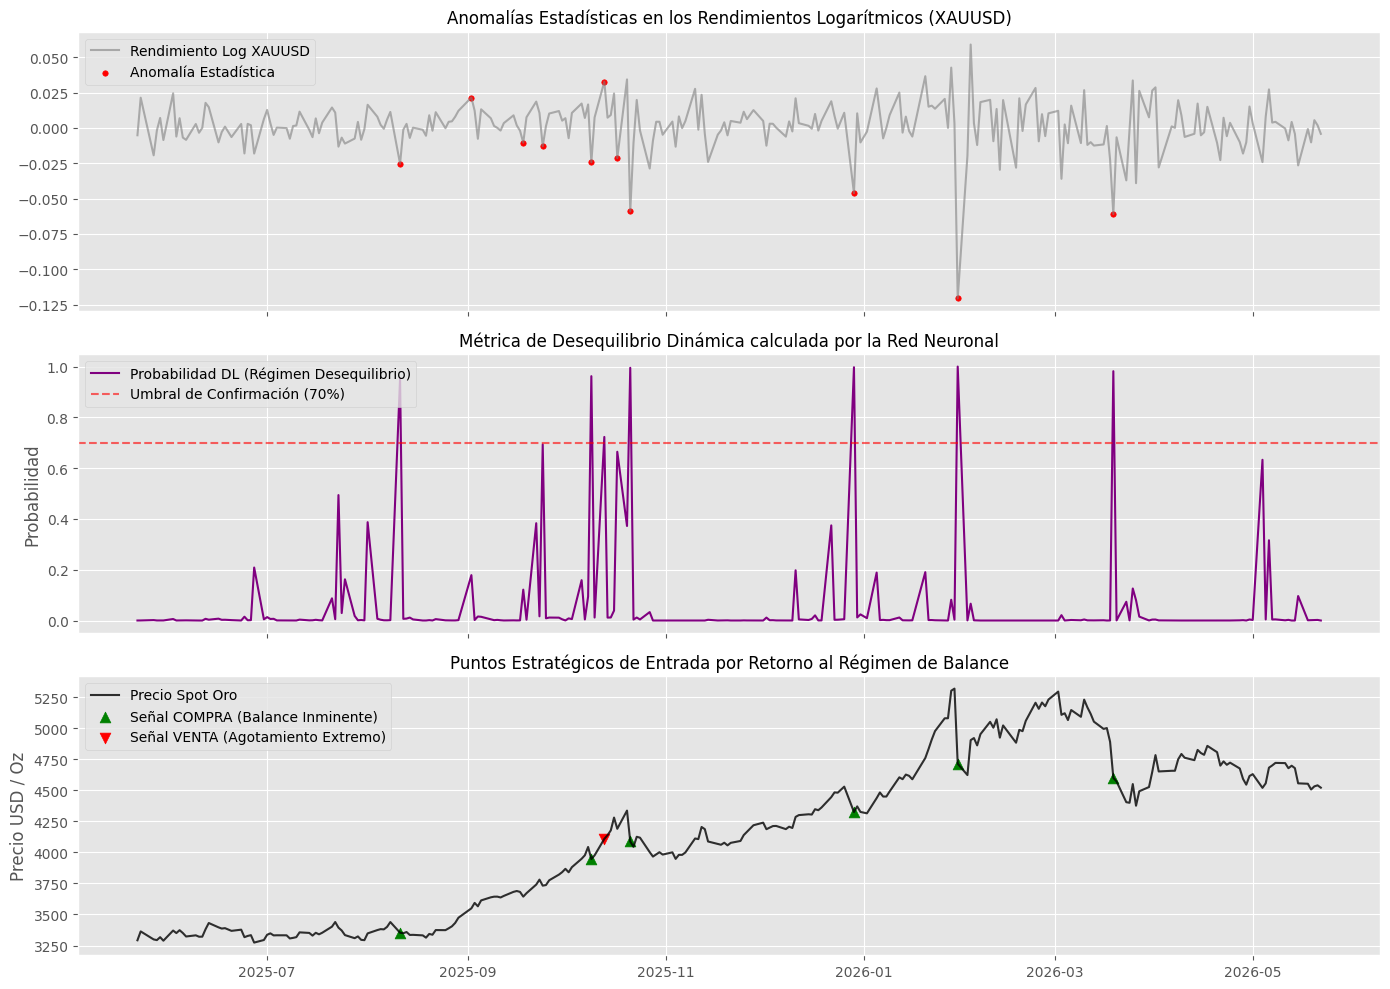

In [18]:
# ==========================================
# 5. VISUALIZACIÓN MULTIGRAFICO DE ANOMALÍAS
# ==========================================
# Filtrar último año para observar el detalle con claridad
if not isinstance(df.index, pd.DatetimeIndex):
    df.index = pd.to_datetime(df.index)

df_viz = df.loc[df.index >= df.index.max() - pd.Timedelta(days=365)]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Gráfico 1: Rendimientos logarítmicos del Oro y anomalías detectadas
axes[0].plot(df_viz.index, df_viz['Log_Return'], color='gray', alpha=0.6, label='Rendimiento Log XAUUSD')
anomalias = df_viz[df_viz['Desequilibrio'] == 1]
axes[0].scatter(anomalias.index, anomalias['Log_Return'], color='red', s=15, label='Anomalía Estadística')
axes[0].set_title('Anomalías Estadísticas en los Rendimientos Logarítmicos (XAUUSD)', fontsize=12)
axes[0].legend(loc='upper left')

# Gráfico 2: Probabilidad de Régimen de Desequilibrio (Salida de la Red Neuronal)
axes[1].plot(df_viz.index, df_viz['Probabilidad_Desequilibrio'], color='purple', label='Probabilidad DL (Régimen Desequilibrio)')
axes[1].axhline(0.7, color='red', linestyle='--', alpha=0.6, label='Umbral de Confirmación (70%)')
axes[1].set_title('Métrica de Desequilibrio Dinámica calculada por la Red Neuronal', fontsize=12)
axes[1].set_ylabel('Probabilidad')
axes[1].legend(loc='upper left')

# Gráfico 3: Señales de Ejecución Estratégica (Compra / Venta)
axes[2].plot(df_viz.index, df_viz['Close'], color='black', alpha=0.8, label='Precio Spot Oro')
compras = df_viz[df_viz['Señal'] == 1]
ventas = df_viz[df_viz['Señal'] == -1]
axes[2].scatter(compras.index, compras['Close'], color='green', marker='^', s=60, label='Señal COMPRA (Balance Inminente)')
axes[2].scatter(ventas.index, ventas['Close'], color='red', marker='v', s=60, label='Señal VENTA (Agotamiento Extremo)')
axes[2].set_title('Puntos Estratégicos de Entrada por Retorno al Régimen de Balance', fontsize=12)
axes[2].set_ylabel('Precio USD / Oz')
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()